In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from kdutils.macro2 import *
from lib.bck002 import rebuild_executed_signal_for_eval
from lib.cux001 import FactorEvaluate1

In [3]:
method = 'ricso2'
instruments = 'rbb'
task_id='113001'
period = 5
param_id = '1018806311332385'
sub_path = 'erband_signal/1002_test'


In [4]:
# basic_path = os.path.join(base_path, method,
#                                   instruments, 'temp', 'model', str(task_id),
#                                   str(period), 'rl', 'backtest', 'equal_weight',
#                                   param_id)
# filename = os.path.join(basic_path, 'equal_weight', '7', 'rollrank2_signal','1002_test','position_data.feather')
# postions_data = pd.read_feather(filename)
# postions_data.head()

basic_path = os.path.join(base_path, method,
                                  instruments, 'temp', 'model', str(task_id),
                                  str(period), 'rl', 'backtest', 'rl',
                                  '1013836755991964')
filename = os.path.join(basic_path, '1018806311332385', 'erband_signal','1002_test','position_data.feather')
postions_data = pd.read_feather(filename)
postions_data.head()

,date,min_time,code,direction,numbers,pair_id,source_value,open_trade_time,close_trade_time,trade_time,signal_type
0,2024-04-18,2104,RB,1,1,1,0.881753,2024-04-18 21:04:00,2024-04-18 21:09:00,2024-04-18 21:04:00,open
1,2024-04-18,2105,RB,1,1,2,0.723062,2024-04-18 21:05:00,2024-04-18 21:10:00,2024-04-18 21:05:00,open
2,2024-04-18,2106,RB,1,1,3,0.735966,2024-04-18 21:06:00,2024-04-18 21:11:00,2024-04-18 21:06:00,open
3,2024-04-18,2107,RB,1,1,4,0.958070,2024-04-18 21:07:00,2024-04-18 21:12:00,2024-04-18 21:07:00,open
4,2024-04-18,2109,RB,-1,1,1,0.881753,2024-04-18 21:04:00,2024-04-18 21:09:00,2024-04-18 21:09:00,close


In [5]:
# base_path1 = os.path.join(base_path, method, instruments, 'temp', 'model',
#                               str(task_id), str(period), 'rl')
# dirs1 = os.path.join(base_path1, "signal", "equal_weight", str(7))
# filename = os.path.join(dirs1, 'rollrank2_signal', '1002_test.feather')
# signal_data = pd.read_feather(filename)
# signal_data

base_path1 = os.path.join(base_path, method, instruments, 'temp', 'model',
                              str(task_id), str(period), 'rl')
dirs1 = os.path.join(base_path1, "signal", "rl", str('1018806311332385'))
filename = os.path.join(dirs1, 'erband_signal', '1002_test.feather')
signal_data = pd.read_feather(filename)
signal_data

,trade_time,code,signal,symbol,task_id,value,confidence,net_er_out,er_value,nxt1_ret_5h
0,2024-04-18 21:04:00,RB,1,rbb9999,113001,"[-0.9177427291870117, 0.2626307010650635, -0.4...",0.881753,0.881753,0.881753,0.000946
1,2024-04-18 21:05:00,RB,1,rbb9999,113001,"[-0.7601301670074463, 0.7531843185424805, 0.29...",0.723062,0.723062,0.723062,0.000422
2,2024-04-18 21:06:00,RB,1,rbb9999,113001,"[-0.21360868215560913, 0.16371333599090576, -0...",0.735966,0.735966,0.735966,0.000629
3,2024-04-18 21:07:00,RB,1,rbb9999,113001,"[-0.7692319750785828, 0.7072559595108032, -0.2...",0.958070,0.958070,0.958070,0.000352
4,2024-04-18 21:08:00,RB,0,rbb9999,113001,"[-0.6830067038536072, -0.211450457572937, -0.1...",0.197368,-0.197368,-0.197368,0.000031
...,...,...,...,...,...,...,...,...,...,...
169613,2026-04-29 22:57:00,RB,0,rbb9999,113001,"[-0.40899789333343506, 0.43656063079833984, 0....",0.270531,0.270531,0.270531,0.000698
169614,2026-04-29 22:58:00,RB,0,rbb9999,113001,"[-0.7708642482757568, -0.030861496925354004, -...",0.200000,0.200000,0.200000,0.000673
169615,2026-04-29 22:59:00,RB,-1,rbb9999,113001,"[0.22344326972961426, -0.4226309061050415, 0.6...",0.801181,-0.801181,-0.801181,0.000891
169616,2026-04-29 23:00:00,RB,-1,rbb9999,113001,"[0.7413473129272461, -0.9282691478729248, 0.97...",0.716914,-0.716914,-0.716914,0.000425


In [6]:
executed_signal = rebuild_executed_signal_for_eval(
    signal_data=signal_data,
    position_data=postions_data,  # 原始完整 position_data，不要提前过滤列
    signal_col="signal",
)
executed_signal = executed_signal[['trade_time','code','signal','nxt1_ret_5h']]#.head()

In [7]:
executed_signal[executed_signal['signal'] == 1]

,trade_time,code,signal,nxt1_ret_5h
0,2024-04-18 21:04:00,RB,1,0.000946
1,2024-04-18 21:05:00,RB,1,0.000422
2,2024-04-18 21:06:00,RB,1,0.000629
3,2024-04-18 21:07:00,RB,1,0.000352
30,2024-04-18 21:34:00,RB,1,-0.000914
...,...,...,...,...
169606,2026-04-29 22:50:00,RB,1,0.000120
169607,2026-04-29 22:51:00,RB,1,-0.000141
169610,2026-04-29 22:54:00,RB,1,-0.000325
169611,2026-04-29 22:55:00,RB,1,0.000093


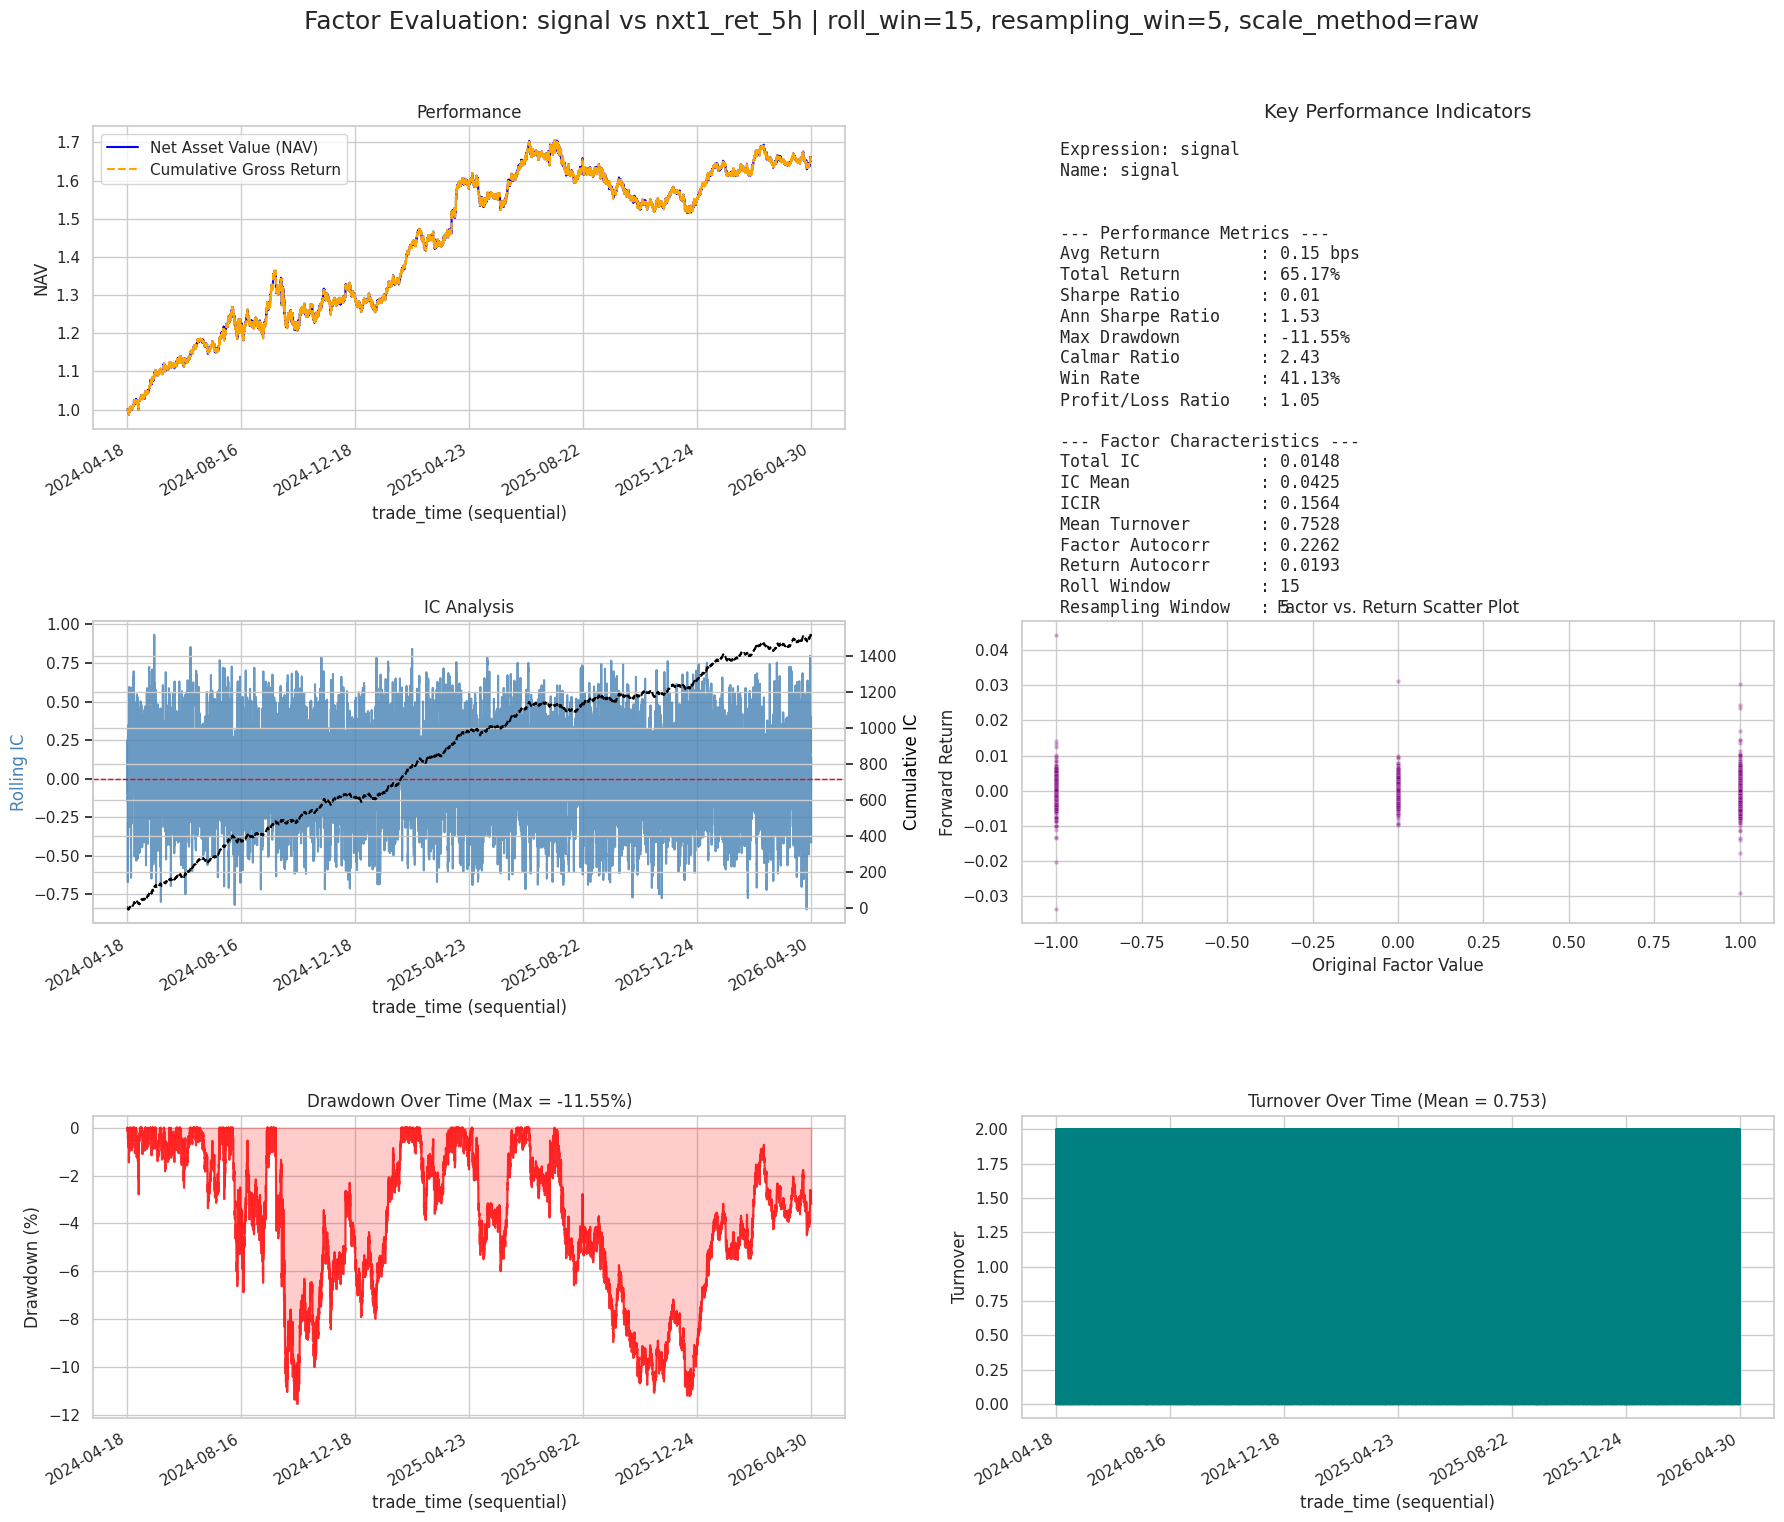

In [8]:
evaluate1 = FactorEvaluate1(factor_data=signal_data,
                                   factor_name='signal',
                                   ret_name='nxt1_ret_{0}h'.format(period),
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="signal",
                                   resampling_win=period,
                                   name="signal")
_ = evaluate1.run()
evaluate1.plot_results()

In [9]:
# postions_data1 = postions_data.merge(signal_data[['trade_time','nxt1_ret_5h']])
# postions_data1.head()

In [10]:
# postions_data1['trade_time'] = pd.to_datetime(postions_data1['trade_time'])
# is_on_mark =  (postions_data1['trade_time'].dt.minute % period) == 0
# postions_data2 = postions_data1[is_on_mark]
# #is_on_mark = self.factor_data.index.get_level_values(
# #level=0).minute % int(self.resampling_win) == 0
# #self.resample_data = self.factor_data[is_on_mark].copy()

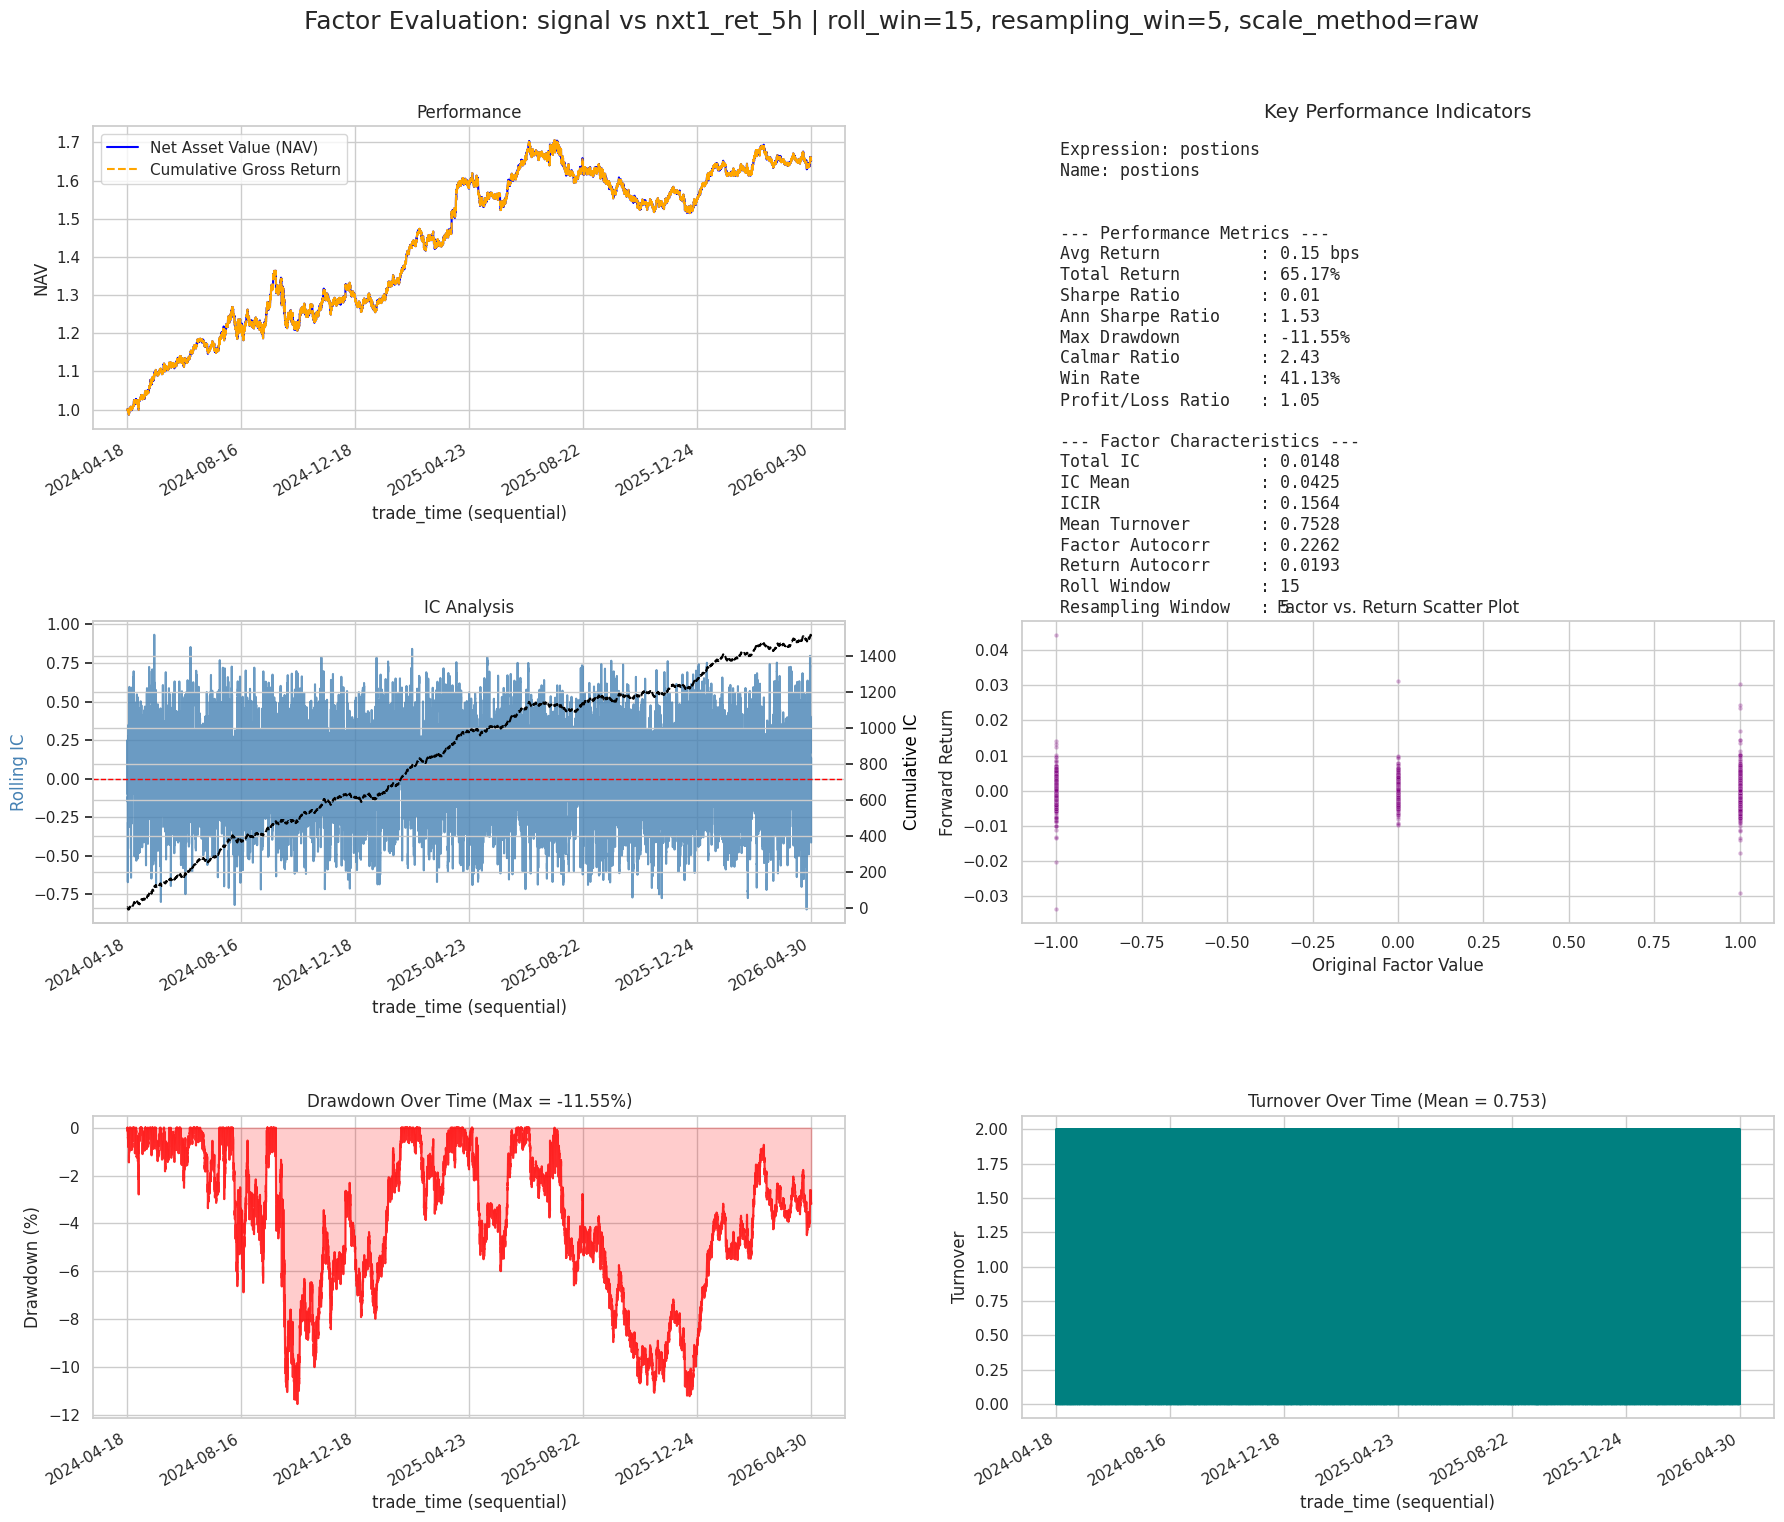

In [11]:
evaluate2 = FactorEvaluate1(factor_data=executed_signal,
                                   factor_name='signal',
                                   ret_name='nxt1_ret_{0}h'.format(period),
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="postions",
                                   resampling_win=period,
                                   name="postions")
_ = evaluate2.run()
evaluate2.plot_results()

In [12]:
### 对比 两个信号差异
cmp = signal_data[["trade_time", "code", "signal"]].copy()
cmp["trade_time"] = pd.to_datetime(cmp["trade_time"])

exe = executed_signal[["trade_time", "code", "signal"]].copy()
exe["trade_time"] = pd.to_datetime(exe["trade_time"])

cmp = cmp.merge(
    exe,
    on=["trade_time", "code"],
    how="inner",
    suffixes=("_raw", "_exec"),
)

print("diff_ratio:", (cmp["signal_raw"] != cmp["signal_exec"]).mean())
print(pd.crosstab(cmp["signal_raw"], cmp["signal_exec"]))

diff_ratio: 0.0
signal_exec     -1      0      1
signal_raw                      
-1           51787      0      0
 0               0  34625      0
 1               0      0  83206


In [13]:
### 这个是做5分钟网格过滤。
raw_grid = signal_data.copy()
raw_grid["trade_time"] = pd.to_datetime(raw_grid["trade_time"])

mask = raw_grid["trade_time"].dt.minute % period == 0
raw_grid["signal_grid"] = raw_grid["signal"]
raw_grid.loc[~mask, "signal_grid"] = 0

cmp2 = raw_grid[["trade_time", "code", "signal", "signal_grid"]].merge(
    executed_signal[["trade_time", "code", "signal"]],
    on=["trade_time", "code"],
    how="inner",
    suffixes=("_raw", "_exec"),
)

print("raw vs grid diff:", (cmp2["signal_raw"] != cmp2["signal_grid"]).mean())
print("grid vs exec diff:", (cmp2["signal_grid"] != cmp2["signal_exec"]).mean())

print(pd.crosstab(cmp2["signal_grid"], cmp2["signal_exec"]))

raw vs grid diff: 0.6289662653727789
grid vs exec diff: 0.6289662653727789
signal_exec     -1      0      1
signal_grid                     
-1           11010      0      0
 0           40777  34625  65907
 1               0      0  17299


In [14]:
cmp_ret = signal_data[[
    "trade_time", "code", "signal", "nxt1_ret_5h"
]].copy()

cmp_ret["trade_time"] = pd.to_datetime(cmp_ret["trade_time"])

exe = executed_signal[["trade_time", "code", "signal"]].copy()
exe["trade_time"] = pd.to_datetime(exe["trade_time"])

cmp_ret = cmp_ret.merge(
    exe,
    on=["trade_time", "code"],
    how="inner",
    suffixes=("_raw", "_exec"),
)

cmp_ret["raw_signed_ret"] = cmp_ret["signal_raw"] * cmp_ret["nxt1_ret_5h"]
cmp_ret["exec_signed_ret"] = cmp_ret["signal_exec"] * cmp_ret["nxt1_ret_5h"]

cmp_ret["status"] = np.where(
    (cmp_ret["signal_raw"] != 0) & (cmp_ret["signal_exec"] == 0),
    "dropped",
    np.where(
        (cmp_ret["signal_raw"] != 0) & (cmp_ret["signal_exec"] != 0),
        "kept",
        "flat",
    )
)

summary = cmp_ret.groupby("status").agg(
    count=("status", "size"),
    raw_signal_mean=("signal_raw", "mean"),
    raw_signed_ret_mean=("raw_signed_ret", "mean"),
    raw_signed_ret_sum=("raw_signed_ret", "sum"),
    win_rate=("raw_signed_ret", lambda x: (x > 0).mean()),
)

summary

,count,raw_signal_mean,raw_signed_ret_mean,raw_signed_ret_sum,win_rate
status,,,,,
flat,34625,0.000000,0.000000,0.000000,0.000000
kept,134993,0.232745,0.000012,1.651586,0.512938


In [15]:
dropped = cmp_ret[cmp_ret["status"] == "dropped"].copy()
dropped["hhmm"] = dropped["trade_time"].dt.strftime("%H:%M")

dropped_time = dropped.groupby("hhmm").agg(
    count=("hhmm", "size"),
    signed_ret_sum=("raw_signed_ret", "sum"),
    signed_ret_mean=("raw_signed_ret", "mean"),
    win_rate=("raw_signed_ret", lambda x: (x > 0).mean()),
).sort_values("count", ascending=False)

dropped_time.head(30)

,count,signed_ret_sum,signed_ret_mean,win_rate
hhmm,,,,


In [16]:
cmp = signal_data[["trade_time", "code", "signal"]].copy()
cmp["trade_time"] = pd.to_datetime(cmp["trade_time"])

exe = executed_signal[["trade_time", "code", "signal"]].copy()
exe["trade_time"] = pd.to_datetime(exe["trade_time"])

cmp = cmp.merge(
    exe,
    on=["trade_time", "code"],
    how="inner",
    suffixes=("_raw", "_exec"),
)

diff_rows = cmp[
    (cmp["signal_raw"] == -1) &
    (cmp["signal_exec"] == 0)
].sort_values(["code", "trade_time"])

diff_rows

,trade_time,code,signal_raw,signal_exec
